In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv(r'C:\K\social-media-dev-crawler\data\Lda\validated_sample.csv')

In [3]:
df.head()

,id,site,new_topic,topics_validation,technologies,subtopics,link,is_valid1,is_valid2
0,13817452,stackoverflow,Random Number Generation & Entropy,True,"SQL server, generation random number",Generating Cryptographic Keys and Unique Rando...,https://stackoverflow.com/questions/13817452,True,True
1,88430,crypto,File Encryption & Data Processing,True,"Python Decrypt files, XOR",Programmatic File Encryption and Decryption Is...,https://crypto.stackexchange.com/questions/88430,True,True
2,6317276,stackoverflow,String/Byte-Level Encryption & Encoding,True,"MD5, hash","String–Byte Conversion, Encoding, and Hashing ...",https://stackoverflow.com/questions/6317276,True,True
3,2532668,stackoverflow,String/Byte-Level Encryption & Encoding,True,"C#, encryption XOR",General Q&A on String Encryption/Decryption in...,https://stackoverflow.com/questions/2532668,True,True
4,26217076,stackoverflow,Hash Functions & Collision Properties,True,"MD5, hash","Hash Output Size, Collisions, and Uniqueness",https://stackoverflow.com/questions/26217076,True,True


## Validations

In [4]:
df.groupby('new_topic')['topics_validation'].mean().sort_values(ascending=False)

new_topic
Hash Functions & Collision Properties                      1.000000
General Cryptography Concepts & Security Discussions       1.000000
File Encryption & Data Processing                          1.000000
User Data Protection & Password Handling                   0.950000
Number Theory & Performance in Cryptographic Algorithms    0.947368
Crypto Code Implementation & Library Issues                0.945946
Password Hashing, Salting & Cracking Defense               0.944444
Random Number Generation & Entropy                         0.909091
Device and Storage Encryption                              0.888889
Public-Key Cryptography & Key Exchange                     0.875000
Block Cipher Modes & Message Encryption                    0.840000
String/Byte-Level Encryption & Encoding                    0.826087
Key Strength, Attacks & Brute-Force Security               0.777778
Certificates, PKI, and Server Authentication               0.705882
Q&A Meta-Discussion (StackOverflow Mec

In [5]:
df['topics_validation'].mean()

np.float64(0.8963210702341137)

In [6]:
df['is_valid1'].mean()

np.float64(0.8193979933110368)

In [7]:
df.groupby('subtopics')['is_valid1'].mean().sort_values(ascending=False)

subtopics
Block Cipher Byte-Level Encryption, Modes, and Padding                   1.0
Choosing and Implementing Cryptographically Secure RNG Functions         1.0
Choosing and Implementing Block Cipher Modes (Performance & Nonces)      1.0
Brute-Force Cost and Quantum Attack Time Estimates                       1.0
Collision Attacks and Practical Hash Security                            1.0
                                                                        ... 
Basic Message Encryption & Decryption                                    0.0
General Q&A: Code-Focused Crypto Problem Solving                         0.0
Detailed Worked Answers & Enigma/Rotors Explanations                     0.0
Software License Keys and Product Activation                             0.0
Public-Key Based Schemes in Applications (Voting, Transactions, etc.)    0.0
Name: is_valid1, Length: 76, dtype: float64

In [8]:
df.groupby(['new_topic', 'subtopics'])['is_valid1'].mean().sort_values()

new_topic                                    subtopics                                                    
Crypto Code Implementation & Library Issues  General Q&A: Code-Focused Crypto Problem Solving                 0.0
                                             Hash Output Size, Collisions, and Uniqueness                     0.0
                                             Public/Private Keys in Files, OpenSSL Usage, and Certificates    0.0
                                             Password-Protected Encrypted Containers and Archives             0.0
Device and Storage Encryption                Programmatic File Encryption and Decryption Issues               0.0
                                                                                                             ... 
User Data Protection & Password Handling     General Application & Database Security Questions                1.0
                                             Key Management for Encrypting User Data           

## Tecnologies

In [9]:
import re
import pandas as pd

def encontrar_linguagem_robusta(tags_texto, linguagens_alvo):
    """
    Verifica se alguma linguagem alvo está presente na string de tags,
    usando uma regex robusta para lidar com caracteres especiais (+, #).
    """
    if pd.isna(tags_texto) or not tags_texto.strip():
        return 'N/A'

    tags_texto_lower = tags_texto.lower()

    for lang in linguagens_alvo:
        lang_lower = lang.lower()
        lang_escaped = re.escape(lang_lower)
        
        regex_busca = r'(^|,\s*)' + lang_escaped + r'(\s*,|$)'
    
        if re.search(regex_busca, tags_texto_lower):
            return lang
            
    return 'N/A'

In [10]:
LANGUAGES = ['Python', 'JavaScript', 'Java', 'PHP', 'C++', 'C#', 'C', 'Go', 'Perl', 'Ruby', 'Delphi']
LOWERCASE_LANGUAGES = [lang.lower() for lang in LANGUAGES]

df['language'] = df['technologies'].str.lower().apply(
    lambda x: encontrar_linguagem_robusta(x, LANGUAGES)
)

In [11]:
df['language'].value_counts() / df.shape[0] * 100

language
N/A           56.856187
Java          14.046823
C#            11.036789
JavaScript     4.682274
PHP            4.682274
Python         3.678930
C++            2.341137
C              1.003344
Go             0.668896
Perl           0.334448
Delphi         0.334448
Ruby           0.334448
Name: count, dtype: float64

<Axes: ylabel='language'>

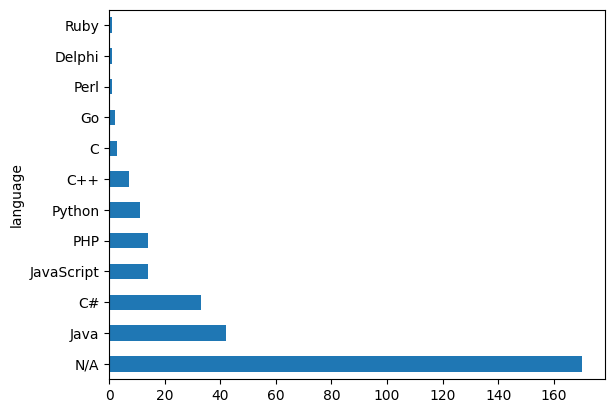

In [12]:
df['language'].value_counts().plot.barh()

In [13]:
def remove_languages_from_technologies(tech_string, languages_to_remove):
    """
    Remove as linguagens especificadas da string de tecnologias.
    """
    if pd.isna(tech_string) or not tech_string.strip():
        return 'N/A'
    
    tech_list = [tech.strip() for tech in tech_string.split(',')]
    filtered_list = [tech for tech in tech_list if tech.lower() not in [lang.lower() for lang in languages_to_remove]]
    
    # Join back
    return ', '.join(filtered_list) if filtered_list else 'N/A'

# Remove languages from technologies column
df['technologies_clean'] = df['technologies'].apply(lambda x: remove_languages_from_technologies(x, LANGUAGES))

In [14]:
exploded = (
    df['technologies_clean']
        .str.split(',')
        .explode()
        .str.strip()
        .str.replace('\xa0', '', regex=False)
        .str.lower()
        .replace('', pd.NA)
        .dropna()
)

In [15]:
contagem_palavras_clean = exploded.value_counts()
contagem_palavras_clean.head(10)

technologies_clean
aes        73
rsa        43
n/a        24
openssl    19
sha        16
md5        13
hmac       12
.net       12
hash       11
base64     10
Name: count, dtype: int64

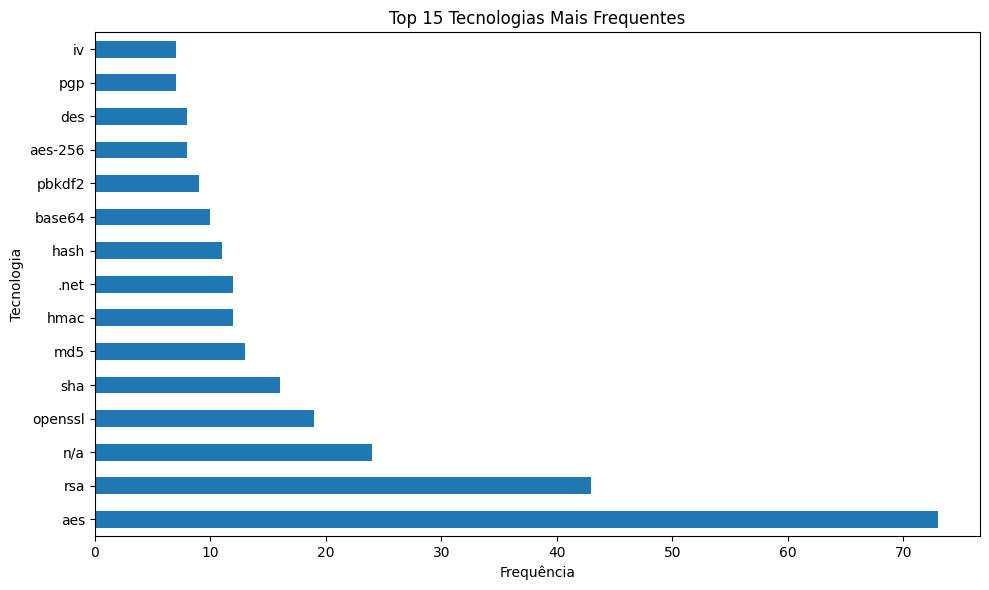

In [16]:
contagem_palavras_clean.head(15).plot.barh(figsize=(10, 6))
plt.title('Top 15 Tecnologias Mais Frequentes')
plt.xlabel('Frequência')
plt.ylabel('Tecnologia')
plt.tight_layout()
plt.show()

In [17]:
pd.set_option('display.max_rows', None)

In [18]:
contagem_palavras_clean / df.shape[0] * 100

technologies_clean
aes                           24.414716
rsa                           14.381271
n/a                            8.026756
openssl                        6.354515
sha                            5.351171
md5                            4.347826
hmac                           4.013378
.net                           4.013378
hash                           3.678930
base64                         3.344482
pbkdf2                         3.010033
aes-256                        2.675585
des                            2.675585
pgp                            2.341137
iv                             2.341137
ssl                            2.006689
encryption                     2.006689
tls                            2.006689
truecrypt                      2.006689
sql server                     1.672241
cryptojs                       1.672241
aes-128                        1.672241
mysql                          1.672241
xor                            1.337793
gcm                  